# 03 - Experiments part1

In [ ]:
import os, random, time
import subprocess
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from transformers import WavLMModel
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# пути
DATASET_ROOT = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset"
LA_ROOT = f"{DATASET_ROOT}/LA/LA"
PROTO_DIR = f"{LA_ROOT}/ASVspoof2019_LA_cm_protocols"
TRAIN_FLAC = f"{LA_ROOT}/ASVspoof2019_LA_train/flac"
DEV_FLAC = f"{LA_ROOT}/ASVspoof2019_LA_dev/flac"
PROTO_TRAIN = f"{PROTO_DIR}/ASVspoof2019.LA.cm.train.trn.txt"
PROTO_DEV = f"{PROTO_DIR}/ASVspoof2019.LA.cm.dev.trl.txt"

# конфиг
DEVICE = torch.device("cuda")
MODEL_NAME = "microsoft/wavlm-large"
MAX_SECONDS = 6.0
SAMPLE_RATE = 16_000
MAX_SAMPLES = int(MAX_SECONDS * SAMPLE_RATE)   # 96 000
N_LAYERS = 25    # 1 CNN + 24 трансформер-слоя
FEAT_DIM = 1024
FEAT_DIR = "/kaggle/working/features_weighted_sum"

BATCH_SIZE = 64
LR = 1e-3
NUM_EPOCHS = 30
PATIENCE = 7
SEED = 42

os.makedirs(FEAT_DIR, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed(SEED)
print(f"N_LAYERS: {N_LAYERS}")
print(f"FEAT_DIR: {FEAT_DIR}")
print(f"CUDA: {torch.cuda.get_device_name(0)}")

N_LAYERS: 25
FEAT_DIR: /kaggle/working/features_weighted_sum
CUDA: Tesla T4


## 1. Данные и протоколы

In [2]:
LABEL2IDX = {"bonafide": 1, "spoof": 0}

def parse_protocol(path):
    rows = []
    with open(path) as f:
        for line in f:
            p = line.split()
            rows.append({"file_id": p[1], "attack": p[3], "label": p[4]})
    return pd.DataFrame(rows)

train_df = parse_protocol(PROTO_TRAIN)
dev_df   = parse_protocol(PROTO_DEV)

n_bon = (train_df.label == "bonafide").sum()
n_spo = (train_df.label == "spoof").sum()
WEIGHT_BONAFIDE = n_spo / n_bon
print(f"train: {len(train_df):,}  dev: {len(dev_df):,}")
print(f"WEIGHT_BONAFIDE = {WEIGHT_BONAFIDE:.1f}")

class AudioDataset(Dataset):
    def __init__(self, df, flac_dir):
        self.df = df.reset_index(drop=True)
        self.flac_dir = flac_dir

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        wav, sr = torchaudio.load(f"{self.flac_dir}/{row.file_id}.flac")
        wav = wav.mean(0)
        if sr != SAMPLE_RATE:
            wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
        if wav.numel() < MAX_SAMPLES:
            reps = MAX_SAMPLES // wav.numel() + 1
            wav  = wav.repeat(reps)[:MAX_SAMPLES]
        else:
            wav = wav[:MAX_SAMPLES]
        return wav, LABEL2IDX[row.label], row.file_id

train_ds = AudioDataset(train_df, TRAIN_FLAC)
dev_ds  = AudioDataset(dev_df,   DEV_FLAC)
print("AudioDataset готов")

train: 25,380  dev: 24,844
WEIGHT_BONAFIDE = 8.8
AudioDataset готов


## 2. Извлечение 25 слоёв WavLM

In [ ]:
model = WavLMModel.from_pretrained(MODEL_NAME)
model.eval().to(DEVICE)
for p in model.parameters():
    p.requires_grad_(False)
print(f"WavLM загружен: {sum(p.numel() for p in model.parameters())/1e6:.1f}M параметров")

def extract_all_layers(dataset, split_name, batch_size=4):
    feat_path  = f"{FEAT_DIR}/{split_name}_features.npy"
    label_path = f"{FEAT_DIR}/{split_name}_labels.npy"

    if os.path.exists(feat_path):
        print(f"{split_name}: найдены сохранённые признаки, загружаем.")
        return np.load(feat_path), np.load(label_path)

    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=False, num_workers=0)
    all_feats, all_labels = [], []

    with torch.no_grad():
        for wavs, labels, _ in tqdm(loader, desc=f"Extracting {split_name}"):
            wavs = wavs.to(DEVICE)
            out  = model(wavs, output_hidden_states=True)
            hidden = torch.stack(out.hidden_states, dim=1)
            feat   = hidden.mean(dim=2)                  # (B, 25, 1024)

            all_feats.append(feat.cpu().numpy())
            all_labels.append(labels.numpy())

    feats  = np.concatenate(all_feats,  axis=0)   # (N, 25, 1024)
    labels = np.concatenate(all_labels, axis=0)   # (N,)
    np.save(feat_path,  feats)
    np.save(label_path, labels)
    print(f"{split_name}: сохранено {feats.shape}  ({feats.nbytes/1e9:.2f} GB)")
    return feats, labels

train_feats, train_labels = extract_all_layers(train_ds, "train")
dev_feats,   dev_labels   = extract_all_layers(dev_ds,   "dev")

# освобождаем GPU — WavLM больше не нужен
del model
torch.cuda.empty_cache()
print(f"\ntrain_feats : {train_feats.shape}")
print(f"dev_feats: {dev_feats.shape}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

WavLM загружен: 315.5M параметров


Extracting train:   0%|          | 0/6345 [00:00<?, ?it/s]

train: сохранено (25380, 25, 1024)  (2.60 GB)


Extracting dev:   0%|          | 0/6211 [00:00<?, ?it/s]

dev: сохранено (24844, 25, 1024)  (2.54 GB)

train_feats : (25380, 25, 1024)
dev_feats: (24844, 25, 1024)


In [ ]:
class AllLayersFeatDataset(Dataset):
    def __init__(self, feats, labels):
        self.feats  = torch.tensor(feats,  dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        return self.feats[i], self.labels[i]

train_feat_ds = AllLayersFeatDataset(train_feats, train_labels)
dev_feat_ds   = AllLayersFeatDataset(dev_feats,   dev_labels)

train_loader = DataLoader(train_feat_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
dev_loader = DataLoader(dev_feat_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

## 3. Weighted Sum probe (Linear) + обучение

In [ ]:
class WeightedSumProbe(nn.Module):
    def __init__(self, n_layers=N_LAYERS, feat_dim=FEAT_DIM, n_classes=2):
        super().__init__()
        self.layer_weights = nn.Parameter(torch.ones(n_layers))
        self.classifier    = nn.Linear(feat_dim, n_classes)

    def forward(self, x):
        w   = torch.softmax(self.layer_weights, dim=0)   # (25,)
        out = (x * w.unsqueeze(0).unsqueeze(-1)).sum(dim=1)  # (B, 1024)
        return self.classifier(out)

    def get_weights(self):
        return torch.softmax(self.layer_weights, dim=0).detach().cpu().numpy()


def compute_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2 * 100, thresholds[idx]


probe = WeightedSumProbe().to(DEVICE)
n_trainable = sum(p.numel() for p in probe.parameters() if p.requires_grad)
print(f"WeightedSumProbe: {n_trainable:,} обучаемых параметров")
print(f"layer_weights: {N_LAYERS}")
print(f"classifier: {FEAT_DIM} × 2 = {FEAT_DIM*2}")

WeightedSumProbe: 2,075 обучаемых параметров
layer_weights: 25
classifier: 1024 × 2 = 2048


In [6]:
weights   = torch.tensor([1.0, WEIGHT_BONAFIDE], dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(probe.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="min", factor=0.5, patience=3)

def run_epoch(loader, probe, criterion, optimizer=None):
    is_train = optimizer is not None
    probe.train() if is_train else probe.eval()
    total_loss, all_labels, all_scores = 0.0, [], []

    with torch.set_grad_enabled(is_train):
        for feats, labels in loader:
            feats, labels = feats.to(DEVICE), labels.to(DEVICE)
            logits = probe(feats)
            loss   = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            scores = torch.softmax(logits, dim=1)[:, 1]
            total_loss  += loss.item() * len(labels)
            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(scores.detach().cpu().numpy())

    eer, _ = compute_eer(np.array(all_labels), np.array(all_scores))
    return total_loss / len(loader.dataset), eer

history = {"train_loss": [], "train_eer": [], "dev_loss": [], "dev_eer": []}
best_dev_eer, best_epoch, patience_cnt = float("inf"), -1, 0

print(f"{'Epoch':>6} {'Train Loss':>11} {'Train EER':>10} {'Dev Loss':>10} {'Dev EER':>9}")

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_eer = run_epoch(train_loader, probe, criterion, optimizer)
    dv_loss, dv_eer = run_epoch(dev_loader,   probe, criterion)
    scheduler.step(dv_loss)

    history["train_loss"].append(tr_loss)
    history["train_eer"].append(tr_eer)
    history["dev_loss"].append(dv_loss)
    history["dev_eer"].append(dv_eer)

    marker = ""
    if dv_eer < best_dev_eer:
        best_dev_eer = dv_eer; best_epoch = epoch; patience_cnt = 0
        torch.save(probe.state_dict(), "/kaggle/working/best_weighted_sum.pt")
        marker = "  best"
    else:
        patience_cnt += 1

    print(f"{epoch:>6} {tr_loss:>11.4f} {tr_eer:>9.2f}% "
          f"{dv_loss:>10.4f} {dv_eer:>8.2f}%{marker}", flush=True)

    if patience_cnt >= PATIENCE:
        print(f"\nEarly stopping на эпохе {epoch}"); break

print(f"\nЛучший dev EER: {best_dev_eer:.2f}%")

 Epoch  Train Loss  Train EER   Dev Loss   Dev EER
     1      0.0943      2.71%     0.0325     0.83%  best
     2      0.0219      0.40%     0.0376     0.82%  best
     3      0.0128      0.19%     0.0107     0.39%  best
     4      0.0077      0.08%     0.0196     0.35%  best
     5      0.0074      0.17%     0.0070     0.32%  best
     6      0.0037      0.01%     0.0060     0.27%  best
     7      0.0034      0.04%     0.0055     0.27%
     8      0.0034      0.05%     0.0045     0.23%  best
     9      0.0027      0.04%     0.0078     0.19%  best
    10      0.0016      0.00%     0.0048     0.32%
    11      0.0013      0.00%     0.0037     0.23%
    12      0.0081      0.31%     0.0040     0.16%  best
    13      0.0008      0.00%     0.0052     0.13%  best
    14      0.0007      0.00%     0.0059     0.16%
    15      0.0005      0.00%     0.0030     0.15%
    16      0.0005      0.00%     0.0047     0.15%
    17      0.0004      0.00%     0.0043     0.17%
    18      0.0004    

Финальный dev EER: 0.11%  (порог=0.0134)


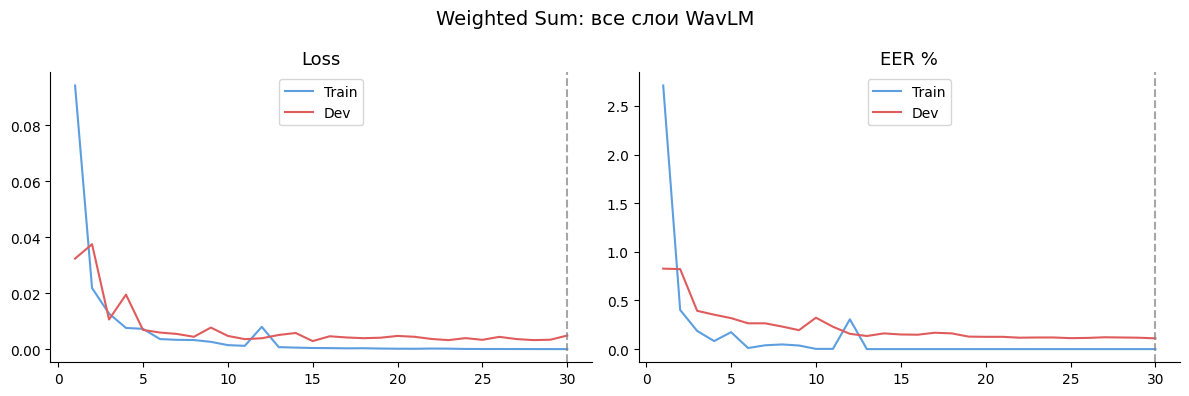

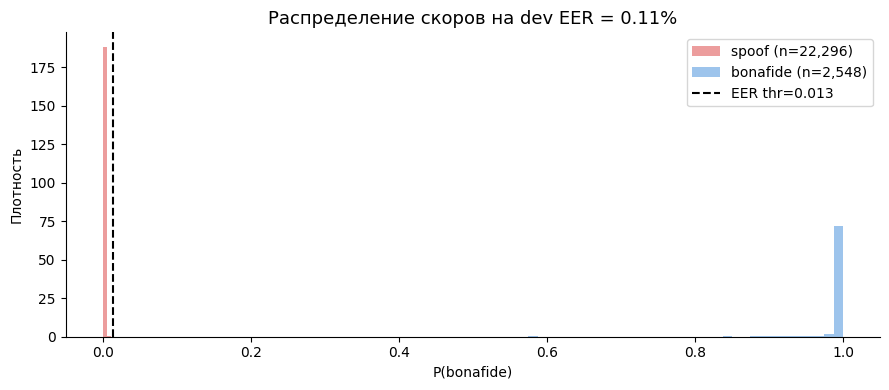

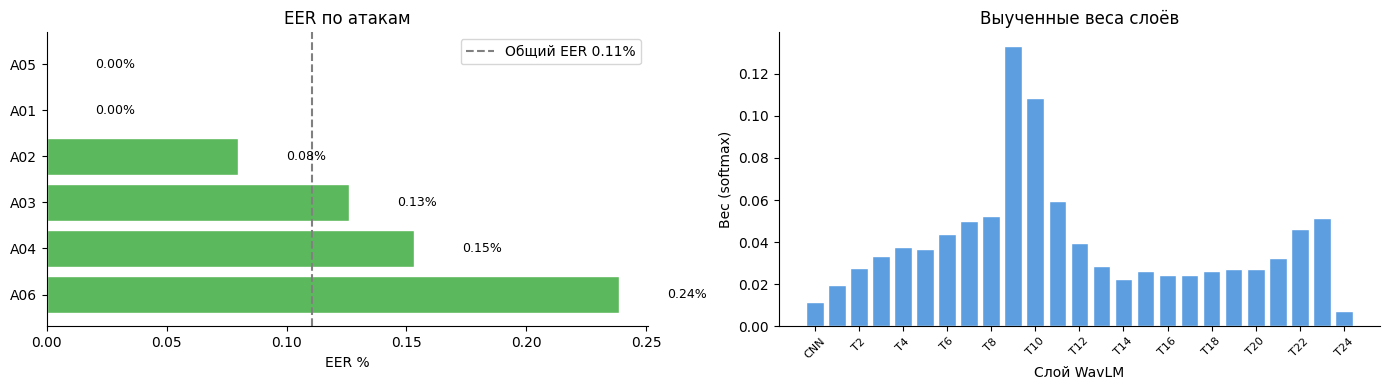

Сравнение: Baseline vs Weighted Sum
                            Baseline  Weighted Sum
Dev EER (общий)                1.84%         0.11%
Dev EER (A06 / VC)             3.78%         0.24%

Изменение общего EER: -1.73%  (улучшение)


In [ ]:
# лучший чекпоинт
probe.load_state_dict(torch.load("/kaggle/working/best_weighted_sum.pt"))
probe.eval()

def get_scores(loader):
    all_labels, all_scores = [], []
    with torch.no_grad():
        for feats, labels in loader:
            logits = probe(feats.to(DEVICE))
            scores = torch.softmax(logits, dim=1)[:, 1]
            all_labels.extend(labels.numpy())
            all_scores.extend(scores.cpu().numpy())
    return np.array(all_labels), np.array(all_scores)

dev_labels_arr, dev_scores_arr = get_scores(dev_loader)
final_eer, final_thr = compute_eer(dev_labels_arr, dev_scores_arr)
print(f"Финальный dev EER: {final_eer:.2f}%  (порог={final_thr:.4f})")

# кривые обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history["train_loss"]) + 1)
for ax, key, title in [(ax1, "loss", "Loss"), (ax2, "eer", "EER %")]:
    ax.plot(epochs, history[f"train_{key}"], color="#5c9ee0", label="Train")
    ax.plot(epochs, history[f"dev_{key}"],   color="#e05c5c", label="Dev")
    ax.axvline(best_epoch, linestyle="--", color="gray", alpha=0.7)
    ax.set_title(title, fontsize=13); ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Weighted Sum: все слои WavLM", fontsize=14)
plt.tight_layout(); plt.show()

# распределение скоров
fig, ax = plt.subplots(figsize=(9, 4))
bon = dev_scores_arr[dev_labels_arr == 1]
spo = dev_scores_arr[dev_labels_arr == 0]
ax.hist(spo, bins=80, alpha=0.6, color="#e05c5c", label=f"spoof (n={len(spo):,})", density=True)
ax.hist(bon, bins=80, alpha=0.6, color="#5c9ee0", label=f"bonafide (n={len(bon):,})", density=True)
ax.axvline(final_thr, color="black", linestyle="--", label=f"EER thr={final_thr:.3f}")
ax.set_xlabel("P(bonafide)"); ax.set_ylabel("Плотность")
ax.set_title(f"Распределение скоров на dev EER = {final_eer:.2f}%", fontsize=13)
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

# EER по атакам
dev_df_scored = dev_df.copy().reset_index(drop=True)
dev_df_scored["score"] = dev_scores_arr
dev_df_scored["label_idx"] = dev_labels_arr
attacks = sorted(dev_df_scored[dev_df_scored.attack != "-"].attack.unique())
bon_mask = dev_df_scored.attack == "-"
rows = []
for atk in attacks:
    subset = dev_df_scored[bon_mask | (dev_df_scored.attack == atk)]
    eer, _ = compute_eer(subset["label_idx"].values, subset["score"].values)
    rows.append({"attack": atk, "EER_weighted": eer})
attack_df = pd.DataFrame(rows).sort_values("EER_weighted", ascending=False)

# веса слоёв
layer_w = probe.get_weights()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
colors = ["#e05c5c" if e > 3 else "#f0a05c" if e > 1 else "#5cb85c"
          for e in attack_df["EER_weighted"]]
bars = ax.barh(attack_df["attack"], attack_df["EER_weighted"],
               color=colors, edgecolor="white")
ax.axvline(final_eer, linestyle="--", color="gray", label=f"Общий EER {final_eer:.2f}%")
ax.set_xlabel("EER %"); ax.set_title("EER по атакам", fontsize=12)
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
for bar, val in zip(bars, attack_df["EER_weighted"]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}%", va="center", fontsize=9)

ax = axes[1]
layer_labels = ["CNN"] + [f"T{i}" for i in range(1, 25)]
ax.bar(range(N_LAYERS), layer_w, color="#5c9ee0", edgecolor="white")
ax.set_xticks(range(0, N_LAYERS, 2))
ax.set_xticklabels(["CNN"] + [f"T{i}" for i in range(2, 25, 2)], rotation=45, fontsize=8)
ax.set_xlabel("Слой WavLM"); ax.set_ylabel("Вес (softmax)")
ax.set_title("Выученные веса слоёв", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

# сравнение с baseline
BASELINE_EER = 1.84
BASELINE_A06 = 3.78
ws_a06 = attack_df[attack_df.attack == "A06"]["EER_weighted"].values[0]
print("Сравнение: Baseline vs Weighted Sum")
print(f"{'':25} {'Baseline':>10} {'Weighted Sum':>13}")
print(f"{'Dev EER (общий)':25} {BASELINE_EER:>9.2f}% {final_eer:>12.2f}%")
print(f"{'Dev EER (A06 / VC)':25} {BASELINE_A06:>9.2f}% {ws_a06:>12.2f}%")
delta = final_eer - BASELINE_EER
print(f"\nИзменение общего EER: {delta:+.2f}%  "
      f"({'улучшение' if delta < 0 else 'ухудшение'})")

## 4. Анализ: послойный probing и веса слоёв

In [9]:
class LinearProbe(nn.Module):
    def __init__(self, in_dim=FEAT_DIM, n_classes=2):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_classes)
    def forward(self, x):
        return self.fc(x)

class SingleLayerDataset(Dataset):
    def __init__(self, feats, labels):
        # feats: (N, 1024) — один слой
        self.feats  = torch.tensor(feats,  dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.feats[i], self.labels[i]

def probe_single_layer(layer_idx, n_epochs=20):
    tr_ds = SingleLayerDataset(train_feats[:, layer_idx, :], train_labels)
    dv_ds = SingleLayerDataset(dev_feats[:,   layer_idx, :], dev_labels)
    tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    dv_ld = DataLoader(dv_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    p   = LinearProbe().to(DEVICE)
    opt = torch.optim.Adam(p.parameters(), lr=LR)
    best_eer = float("inf")

    for _ in range(n_epochs):
        run_epoch(tr_ld, p, criterion, opt)
        _, dv_eer = run_epoch(dv_ld, p, criterion)
        if dv_eer < best_eer:
            best_eer = dv_eer
    return best_eer

layer_eers = []
layer_names = ["CNN"] + [f"T{i}" for i in range(1, N_LAYERS)]

print(f"{'Слой':>6}  {'EER%':>7}")

for i in tqdm(range(N_LAYERS), desc="Layer probing"):
    eer = probe_single_layer(i)
    layer_eers.append(eer)
    print(f"{layer_names[i]:>6}  {eer:>6.2f}%", flush=True)

print(f"\nЛучший слой: {layer_names[int(np.argmin(layer_eers))]}  "
      f"EER={min(layer_eers):.2f}%")
print(f"Худший слой: {layer_names[int(np.argmax(layer_eers))]}  "
      f"EER={max(layer_eers):.2f}%")

  Слой     EER%


Layer probing:   0%|          | 0/25 [00:00<?, ?it/s]

   CNN    2.98%
    T1    0.26%
    T2    0.27%
    T3    0.15%
    T4    0.19%
    T5    0.19%
    T6    0.10%
    T7    0.12%
    T8    0.19%
    T9    0.20%
   T10    0.21%
   T11    0.23%
   T12    0.12%
   T13    0.23%
   T14    0.27%
   T15    0.34%
   T16    0.47%
   T17    0.56%
   T18    0.75%
   T19    0.70%
   T20    0.96%
   T21    0.89%
   T22    0.94%
   T23    1.15%
   T24    2.16%

Лучший слой: T6  EER=0.10%
Худший слой: CNN  EER=2.98%


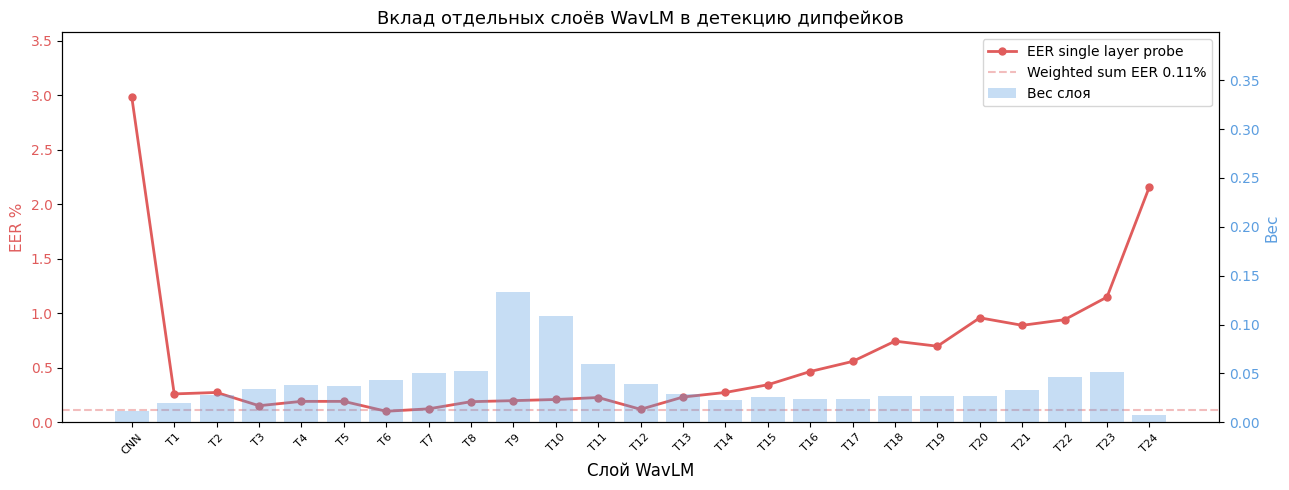

In [10]:
layer_w = probe.get_weights()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

x = range(N_LAYERS)

# EER по слоям
ax1.plot(x, layer_eers, color="#e05c5c", marker="o",
         markersize=5, linewidth=2, label="EER single layer probe")
ax1.axhline(final_eer, linestyle="--", color="#e05c5c", alpha=0.4,
            label=f"Weighted sum EER {final_eer:.2f}%")
ax1.set_xlabel("Слой WavLM", fontsize=12)
ax1.set_ylabel("EER %", color="#e05c5c", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#e05c5c")
ax1.set_ylim(0, max(layer_eers) * 1.2)

# веса weighted sum
ax2.bar(x, layer_w, alpha=0.35, color="#5c9ee0",
        label="Вес слоя")
ax2.set_ylabel("Вес", color="#5c9ee0", fontsize=11)
ax2.tick_params(axis="y", labelcolor="#5c9ee0")
ax2.set_ylim(0, max(layer_w) * 3)

# подписи оси X
ax1.set_xticks(list(x))
ax1.set_xticklabels(layer_names, rotation=45, fontsize=8)

# совместная легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper right", fontsize=10)

plt.title("Вклад отдельных слоёв WavLM в детекцию дипфейков",
          fontsize=13)
plt.tight_layout()
plt.show()

### Многосидовая оценка и bootstrap-CI

In [ ]:
def bootstrap_eer_ci(labels, scores, n_bootstrap=1000, ci=95):
    rng   = np.random.default_rng(SEED)
    n     = len(labels)
    eers  = []
    for _ in range(n_bootstrap):
        idx      = rng.integers(0, n, size=n)
        eer, _   = compute_eer(labels[idx], scores[idx])
        eers.append(eer)
    eers = np.array(eers)
    lo   = np.percentile(eers, (100 - ci) / 2)
    hi   = np.percentile(eers, 100 - (100 - ci) / 2)
    return np.mean(eers), lo, hi

mean_eer, lo, hi = bootstrap_eer_ci(dev_labels_arr, dev_scores_arr)
print(f"Bootstrap EER:")
print(f"mean = {mean_eer:.3f}%")
print(f"95%  CI: [{lo:.3f}%, {hi:.3f}%]")

Bootstrap EER:
mean = 0.133%
95%  CI: [0.060%, 0.238%]


In [12]:
SEEDS = [42, 1, 2026]
seed_results = []

for seed in SEEDS:
    set_seed(seed)
    probe_s = WeightedSumProbe().to(DEVICE)
    opt_s = torch.optim.Adam(probe_s.parameters(), lr=LR)
    crit_s = nn.CrossEntropyLoss(
        weight=torch.tensor([1.0, WEIGHT_BONAFIDE],
                            dtype=torch.float32).to(DEVICE))  # ← фикс
    sched_s = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt_s, mode="min", factor=0.5, patience=3)

    best_eer_s, pat_s = float("inf"), 0
    best_state = None

    for epoch in range(NUM_EPOCHS):
        run_epoch(train_loader, probe_s, crit_s, opt_s)
        _, dv_eer = run_epoch(dev_loader, probe_s, crit_s)
        sched_s.step(dv_eer)
        if dv_eer < best_eer_s:
            best_eer_s = dv_eer
            best_state = {k: v.clone() for k, v in probe_s.state_dict().items()}
            pat_s = 0
        else:
            pat_s += 1
        if pat_s >= PATIENCE:
            break

    probe_s.load_state_dict(best_state)
    probe_s.eval()
    all_l, all_s = [], []
    with torch.no_grad():
        for feats, labels in dev_loader:
            logits = probe_s(feats.to(DEVICE))
            scores = torch.softmax(logits, dim=1)[:, 1]
            all_l.extend(labels.numpy())
            all_s.extend(scores.cpu().numpy())
    eer_final, _ = compute_eer(np.array(all_l), np.array(all_s))
    _, lo_s, hi_s = bootstrap_eer_ci(np.array(all_l), np.array(all_s))
    seed_results.append({"seed": seed, "eer": eer_final, "ci_lo": lo_s, "ci_hi": hi_s})
    print(f"seed={seed:>5}  EER={eer_final:.3f}%  95%CI=[{lo_s:.3f}%, {hi_s:.3f}%]",
          flush=True)

eers  = [r["eer"] for r in seed_results]
mean_ = np.mean(eers)
std_  = np.std(eers)
print(f"\nWeighted Sum:  EER = {mean_:.3f}% ± {std_:.3f}%")

seed=   42  EER=0.126%  95%CI=[0.078%, 0.241%]
seed=    1  EER=0.104%  95%CI=[0.051%, 0.275%]
seed= 2026  EER=0.095%  95%CI=[0.042%, 0.275%]

Weighted Sum:  EER = 0.108% ± 0.013%


## 5. Weighted Sum + MLP

In [ ]:
class WeightedSumMLPProbe(nn.Module):
    def __init__(self, n_layers=N_LAYERS, feat_dim=FEAT_DIM,
                 hidden_dim=256, dropout=0.3, n_classes=2):
        super().__init__()
        self.layer_weights = nn.Parameter(torch.ones(n_layers))
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        w   = torch.softmax(self.layer_weights, dim=0)
        out = (x * w.unsqueeze(0).unsqueeze(-1)).sum(dim=1)  # (B, 1024)
        return self.classifier(out)

    def get_weights(self):
        return torch.softmax(self.layer_weights, dim=0).detach().cpu().numpy()


probe_mlp = WeightedSumMLPProbe().to(DEVICE)
n_trainable = sum(p.numel() for p in probe_mlp.parameters() if p.requires_grad)

In [16]:
SEEDS = [42, 1, 2026]
mlp_seed_results = []
mlp_history_first_seed = None

for seed_i, seed in enumerate(SEEDS):
    set_seed(seed)
    probe_mlp = WeightedSumMLPProbe().to(DEVICE)
    opt_m   = torch.optim.Adam(probe_mlp.parameters(), lr=LR)
    crit_m  = nn.CrossEntropyLoss(
        weight=torch.tensor([1.0, WEIGHT_BONAFIDE], dtype=torch.float32).to(DEVICE))
    sched_m = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt_m, mode="min", factor=0.5, patience=3)

    best_eer_m, pat_m, best_state = float("inf"), 0, None
    hist = {"train_loss": [], "train_eer": [], "dev_loss": [], "dev_eer": []}

    for epoch in range(NUM_EPOCHS):
        tr_loss, tr_eer = run_epoch(train_loader, probe_mlp, crit_m, opt_m)
        dv_loss, dv_eer = run_epoch(dev_loader, probe_mlp, crit_m)
        sched_m.step(dv_loss)
        hist["train_loss"].append(tr_loss); hist["train_eer"].append(tr_eer)
        hist["dev_loss"].append(dv_loss);   hist["dev_eer"].append(dv_eer)

        if dv_eer < best_eer_m:
            best_eer_m = dv_eer
            best_state = {k: v.clone() for k, v in probe_mlp.state_dict().items()}
            pat_m = 0
        else:
            pat_m += 1
        if pat_m >= PATIENCE:
            break

    if seed_i == 0:
        mlp_history_first_seed = hist
        torch.save(best_state, "/kaggle/working/best_weighted_sum_mlp.pt")

    probe_mlp.load_state_dict(best_state)
    probe_mlp.eval()
    all_l, all_s = [], []
    with torch.no_grad():
        for feats, labels in dev_loader:
            logits = probe_mlp(feats.to(DEVICE))
            scores = torch.softmax(logits, dim=1)[:, 1]
            all_l.extend(labels.numpy())
            all_s.extend(scores.cpu().numpy())
    eer_final, _ = compute_eer(np.array(all_l), np.array(all_s))
    _, lo_m, hi_m = bootstrap_eer_ci(np.array(all_l), np.array(all_s))
    mlp_seed_results.append({"seed": seed, "eer": eer_final, "ci_lo": lo_m, "ci_hi": hi_m})
    print(f"seed={seed:>5}  EER={eer_final:.3f}%  95%CI=[{lo_m:.3f}%, {hi_m:.3f}%]",
          flush=True)

mlp_eers = [r["eer"] for r in mlp_seed_results]
mlp_mean = np.mean(mlp_eers)
mlp_std = np.std(mlp_eers)
print(f"\nWeighted Sum + MLP:  EER = {mlp_mean:.3f}% ± {mlp_std:.3f}%")

seed=   42  EER=0.112%  95%CI=[0.042%, 0.313%]
seed=    1  EER=0.108%  95%CI=[0.040%, 0.285%]
seed= 2026  EER=0.072%  95%CI=[0.016%, 0.272%]

Weighted Sum + MLP:  EER = 0.097% ± 0.018%


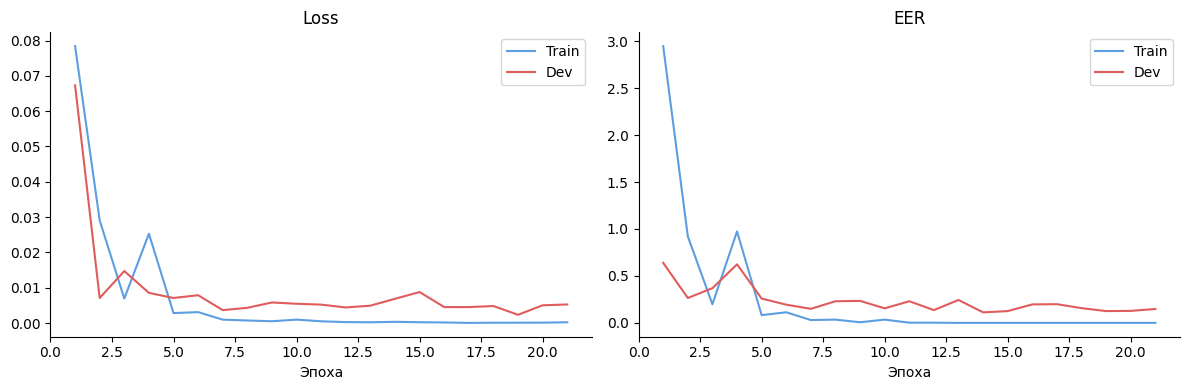

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(mlp_history_first_seed["train_loss"]) + 1)
ax1.plot(epochs, mlp_history_first_seed["train_loss"], color="#5c9ee0", label="Train")
ax1.plot(epochs, mlp_history_first_seed["dev_loss"],   color="#e05c5c", label="Dev")
ax1.set_title("Loss", fontsize=12)
ax1.set_xlabel("Эпоха"); ax1.legend()
ax1.spines[["top", "right"]].set_visible(False)

ax2.plot(epochs, mlp_history_first_seed["train_eer"], color="#5c9ee0", label="Train")
ax2.plot(epochs, mlp_history_first_seed["dev_eer"],   color="#e05c5c", label="Dev")
ax2.set_title("EER", fontsize=12)
ax2.set_xlabel("Эпоха"); ax2.legend()
ax2.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [ ]:
def compute_metrics(labels, scores, threshold=0.5):
    eer, eer_thr = compute_eer(labels, scores)
    auc = roc_auc_score(labels, scores) * 100

    preds_05  = (scores >= 0.5).astype(int)
    preds_eer = (scores >= eer_thr).astype(int)

    return {
        "EER%": eer,
        "AUC%": auc,
        "Accuracy@0.5%": accuracy_score(labels, preds_05) * 100,
        "F1_bonafide@0.5%": f1_score(labels, preds_05, pos_label=1) * 100,
        "Precision_bonafide@0.5%": precision_score(labels, preds_05, pos_label=1) * 100,
        "Recall_bonafide@0.5%": recall_score(labels, preds_05, pos_label=1) * 100,
        "Accuracy@EER_thr%": accuracy_score(labels, preds_eer) * 100,
        "F1_bonafide@EER_thr%": f1_score(labels, preds_eer, pos_label=1) * 100,
        "eer_threshold": eer_thr,
    }

print("compute_metrics определена")

compute_metrics определена


In [ ]:
metrics_linear = compute_metrics(dev_labels_arr, dev_scores_arr)
probe_mlp_best = WeightedSumMLPProbe().to(DEVICE)
probe_mlp_best.load_state_dict(torch.load("/kaggle/working/best_weighted_sum_mlp.pt"))
probe_mlp_best.eval()

mlp_labels_arr, mlp_scores_arr = [], []
with torch.no_grad():
    for feats, labels in dev_loader:
        logits = probe_mlp_best(feats.to(DEVICE))
        scores = torch.softmax(logits, dim=1)[:, 1]
        mlp_labels_arr.extend(labels.numpy())
        mlp_scores_arr.extend(scores.cpu().numpy())
mlp_labels_arr = np.array(mlp_labels_arr)
mlp_scores_arr = np.array(mlp_scores_arr)

metrics_mlp = compute_metrics(mlp_labels_arr, mlp_scores_arr)

# таблица сравнения
comparison_df = pd.DataFrame({
    "Weighted Sum + Linear": metrics_linear,
    "Weighted Sum + MLP":    metrics_mlp,
}).T
comparison_df = comparison_df.drop(columns=["eer_threshold"])
print(comparison_df.round(3))

                        EER%    AUC%  Accuracy@0.5%  F1_bonafide@0.5%  \
Weighted Sum + Linear  0.110  99.997         99.839            99.209   
Weighted Sum + MLP     0.112  99.997         99.775            98.889   

                       Precision_bonafide@0.5%  Recall_bonafide@0.5%  \
Weighted Sum + Linear                    100.0                98.430   
Weighted Sum + MLP                       100.0                97.802   

                       Accuracy@EER_thr%  F1_bonafide@EER_thr%  
Weighted Sum + Linear             99.895                99.492  
Weighted Sum + MLP                99.924                99.628  


## 6. Fine-tuning T6–T12

In [ ]:
class FineTunedWavLM(nn.Module):
    def __init__(self, model_name=MODEL_NAME, unfreeze_layers=range(6, 13),
                 n_classes=2):
        super().__init__()
        self.wavlm = WavLMModel.from_pretrained(model_name)

        for p in self.wavlm.parameters():
            p.requires_grad_(False)

        self.unfrozen_idx = list(unfreeze_layers)
        for idx in self.unfrozen_idx:
            for p in self.wavlm.encoder.layers[idx].parameters():
                p.requires_grad_(True)

        self.classifier = nn.Linear(1024, n_classes)

    def forward(self, wavs):
        out    = self.wavlm(wavs).last_hidden_state
        pooled = out.mean(dim=1)
        return self.classifier(pooled)

    def trainable_summary(self):
        wavlm_tr = sum(p.numel() for p in self.wavlm.parameters() if p.requires_grad)
        clf_tr = sum(p.numel() for p in self.classifier.parameters())
        total = sum(p.numel() for p in self.parameters())
        return wavlm_tr, clf_tr, total

ft_model = FineTunedWavLM(unfreeze_layers=range(6, 13)).to(DEVICE)
wavlm_tr, clf_tr, total = ft_model.trainable_summary()
print(f"Разморожены слои T6-T12")
print(f"Обучаемых параметров WavLM: {wavlm_tr:,}")
print(f"Обучаемых параметров classifier: {clf_tr:,}")
print(f"Всего параметров модели: {total:,}")

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

Разморожены слои T6-T12
Обучаемых параметров WavLM: 88,177,320
Обучаемых параметров classifier: 2,050
Всего параметров модели: 315,455,170


In [ ]:
class RawAudioDataset(Dataset):
    def __init__(self, df, flac_dir):
        self.df = df.reset_index(drop=True)
        self.flac_dir = flac_dir

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        wav, sr = torchaudio.load(f"{self.flac_dir}/{row.file_id}.flac")
        wav = wav.mean(0)
        if sr != SAMPLE_RATE:
            wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
        if wav.numel() < MAX_SAMPLES:
            reps = MAX_SAMPLES // wav.numel() + 1
            wav  = wav.repeat(reps)[:MAX_SAMPLES]
        else:
            wav = wav[:MAX_SAMPLES]
        return wav, LABEL2IDX[row.label]

In [ ]:
# гиперпараметры fine-tuning
FT_BATCH_SIZE        = 16
FT_LR_WAVLM          = 1e-5
FT_LR_CLASSIFIER     = 1e-3
FT_NUM_EPOCHS        = 5
FT_PATIENCE          = 3
FT_TRAIN_SUBSET_FRAC = 0.3
FT_DEV_SUBSET_FRAC   = 0.3

In [ ]:
def stratified_subset(df, frac, seed=SEED):
    idx, _ = train_test_split(
        df.index, train_size=frac,
        stratify=df["label"], random_state=seed)
    return df.loc[idx].reset_index(drop=True)

ft_train_df_sub = stratified_subset(train_df, FT_TRAIN_SUBSET_FRAC)
ft_dev_df_sub   = stratified_subset(dev_df,   FT_DEV_SUBSET_FRAC)

print(f"Train subset: {len(ft_train_df_sub):,} "
      f"(bonafide={sum(ft_train_df_sub.label=='bonafide')}, "
      f"spoof={sum(ft_train_df_sub.label=='spoof')})")
print(f"Dev subset:   {len(ft_dev_df_sub):,} "
      f"(bonafide={sum(ft_dev_df_sub.label=='bonafide')}, "
      f"spoof={sum(ft_dev_df_sub.label=='spoof')})")

ft_train_ds = RawAudioDataset(ft_train_df_sub, TRAIN_FLAC)
ft_dev_ds   = RawAudioDataset(ft_dev_df_sub,   DEV_FLAC)

ft_train_loader = DataLoader(ft_train_ds, batch_size=FT_BATCH_SIZE,
                             shuffle=True, num_workers=2, pin_memory=True)
ft_dev_loader = DataLoader(ft_dev_ds, batch_size=FT_BATCH_SIZE,
                             shuffle=False, num_workers=2, pin_memory=True)

Train subset: 7,614 (bonafide=774, spoof=6840)
Dev subset:   7,453 (bonafide=764, spoof=6689)


In [ ]:
set_seed(SEED)
ft_model = FineTunedWavLM(unfreeze_layers=range(6, 13)).to(DEVICE)

opt_ft = torch.optim.AdamW([
    {"params": [p for p in ft_model.wavlm.parameters() if p.requires_grad],
     "lr": FT_LR_WAVLM},
    {"params": ft_model.classifier.parameters(), "lr": FT_LR_CLASSIFIER},
])
crit_ft = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, WEIGHT_BONAFIDE], dtype=torch.float32).to(DEVICE))
sched_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_ft, mode="min", factor=0.5, patience=1)
scaler = GradScaler('cuda')


def run_epoch_ft(loader, model, criterion, optimizer=None, use_amp=True):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_labels, all_scores = 0.0, [], []

    with torch.set_grad_enabled(is_train):
        for wavs, labels in tqdm(loader, leave=False):
            wavs, labels = wavs.to(DEVICE), labels.to(DEVICE)

            with autocast('cuda', enabled=use_amp):
                logits = model(wavs)
                loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            scores = torch.softmax(logits.float(), dim=1)[:, 1]
            total_loss += loss.item() * len(labels)
            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(scores.detach().cpu().numpy())

    eer, _ = compute_eer(np.array(all_labels), np.array(all_scores))
    return total_loss / len(loader.dataset), eer

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

In [40]:
ft_history = {"train_loss": [], "train_eer": [], "dev_loss": [], "dev_eer": []}
best_ft_eer, best_ft_epoch, ft_patience_cnt = float("inf"), -1, 0

print(f"{'Epoch':>6} {'Train Loss':>11} {'Train EER':>10} {'Dev Loss':>10} {'Dev EER':>9}")

for epoch in range(1, FT_NUM_EPOCHS + 1):
    tr_loss, tr_eer = run_epoch_ft(ft_train_loader, ft_model, crit_ft, opt_ft)
    dv_loss, dv_eer = run_epoch_ft(ft_dev_loader,   ft_model, crit_ft)
    sched_ft.step(dv_loss)

    ft_history["train_loss"].append(tr_loss); ft_history["train_eer"].append(tr_eer)
    ft_history["dev_loss"].append(dv_loss);   ft_history["dev_eer"].append(dv_eer)

    marker = ""
    if dv_eer < best_ft_eer:
        best_ft_eer, best_ft_epoch, ft_patience_cnt = dv_eer, epoch, 0
        torch.save(ft_model.state_dict(), "/kaggle/working/best_finetuned.pt")
        marker = "  best"
    else:
        ft_patience_cnt += 1

    print(f"{epoch:>6} {tr_loss:>11.4f} {tr_eer:>9.2f}% "
          f"{dv_loss:>10.4f} {dv_eer:>8.2f}%{marker}", flush=True)

    if ft_patience_cnt >= FT_PATIENCE:
        print(f"\nEarly stopping на эпохе {epoch}"); break

print(f"\nЛучший dev EER: {best_ft_eer:.2f}%  (эпоха {best_ft_epoch})")

 Epoch  Train Loss  Train EER   Dev Loss   Dev EER


  0%|          | 0/476 [00:00<?, ?it/s]

  0%|          | 0/466 [00:00<?, ?it/s]

     1      0.3215     11.58%     0.3618     3.41%  best


  0%|          | 0/476 [00:00<?, ?it/s]

...

  0%|          | 0/466 [00:00<?, ?it/s]

     4      0.0470      1.49%     0.2690     0.24%  best


  0%|          | 0/476 [00:00<?, ?it/s]

  0%|          | 0/466 [00:00<?, ?it/s]

     5      0.0233      0.59%     0.4889     0.62%

Лучший dev EER: 0.24%  (эпоха 4)


## 7. RawBoost-аугментация

In [ ]:
def rawboost_augment(wav: np.ndarray, sr: int = SAMPLE_RATE, p: float = 0.5):
    wav = wav.copy()

    # 1 Линейные искажения каналов
    if np.random.rand() < p:
        n_bands  = np.random.randint(3, 6)
        gains    = np.random.uniform(0.5, 1.5, n_bands)
        band_len = len(wav) // n_bands
        for i, g in enumerate(gains):
            start, end = i * band_len, (i + 1) * band_len
            wav[start:end] *= g

    # 2 Нелинейные искажения
    if np.random.rand() < p:
        alpha = np.random.uniform(0.1, 0.3)
        wav = wav + alpha * np.sign(wav) * (wav ** 2)

    # 3 Аддитивный шум
    if np.random.rand() < p:
        noise_level = np.random.uniform(0.001, 0.01)
        wav = wav + np.random.normal(0, noise_level, size=wav.shape)

    # нормализация после искажений
    max_val = np.abs(wav).max()
    if max_val > 0:
        wav = wav / max_val * 0.95

    return wav.astype(np.float32)

In [ ]:
class RawAudioDatasetAugmented(Dataset):
    def __init__(self, df, flac_dir, augment=False, augment_p=0.5):
        self.df = df.reset_index(drop=True)
        self.flac_dir  = flac_dir
        self.augment   = augment
        self.augment_p = augment_p

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        wav, sr = torchaudio.load(f"{self.flac_dir}/{row.file_id}.flac")
        wav = wav.mean(0).numpy()

        if sr != SAMPLE_RATE:
            wav_t = torch.from_numpy(wav)
            wav_t = torchaudio.functional.resample(wav_t, sr, SAMPLE_RATE)
            wav = wav_t.numpy()

        if self.augment:
            wav = rawboost_augment(wav, sr=SAMPLE_RATE, p=self.augment_p)

        wav = torch.from_numpy(wav)
        if wav.numel() < MAX_SAMPLES:
            reps = MAX_SAMPLES // wav.numel() + 1
            wav  = wav.repeat(reps)[:MAX_SAMPLES]
        else:
            wav = wav[:MAX_SAMPLES]

        return wav, LABEL2IDX[row.label]

In [ ]:
class WeightedSumProbeEndToEnd(nn.Module):
    def __init__(self, model_name=MODEL_NAME, n_layers=N_LAYERS,
                 feat_dim=FEAT_DIM, n_classes=2):
        super().__init__()
        self.wavlm = WavLMModel.from_pretrained(model_name)
        for p in self.wavlm.parameters():
            p.requires_grad_(False)

        self.layer_weights = nn.Parameter(torch.ones(n_layers))
        self.classifier     = nn.Linear(feat_dim, n_classes)

    def forward(self, wavs):
        with torch.no_grad():
            out    = self.wavlm(wavs, output_hidden_states=True)
            hidden = torch.stack(out.hidden_states, dim=1)
            pooled = hidden.mean(dim=2)

        w   = torch.softmax(self.layer_weights, dim=0)
        agg = (pooled * w.unsqueeze(0).unsqueeze(-1)).sum(dim=1)
        return self.classifier(agg)

    def get_weights(self):
        return torch.softmax(self.layer_weights, dim=0).detach().cpu().numpy()

In [ ]:
rb_train_ds_full = RawAudioDatasetAugmented(train_df, TRAIN_FLAC, augment=True)
rb_dev_ds_full    = RawAudioDatasetAugmented(dev_df,   DEV_FLAC,   augment=False)

rb_train_loader_full = DataLoader(rb_train_ds_full, batch_size=FT_BATCH_SIZE,
                                  shuffle=True, num_workers=2, pin_memory=True)
rb_dev_loader_full   = DataLoader(rb_dev_ds_full, batch_size=FT_BATCH_SIZE,
                                  shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
def extract_weighted_sum_features(loader, model):
    model.eval()
    all_feats, all_labels = [], []
    with torch.no_grad():
        for wavs, labels in tqdm(loader, desc="Extracting dev features"):
            wavs = wavs.to(DEVICE)
            out  = model.wavlm(wavs, output_hidden_states=True)
            hidden = torch.stack(out.hidden_states, dim=1)
            pooled = hidden.mean(dim=2)  # (B, 25, 1024)
            all_feats.append(pooled.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_feats, axis=0), np.concatenate(all_labels, axis=0)

test_model = WeightedSumProbeEndToEnd().to(DEVICE)
rb_dev_feats_cached, rb_dev_labels_cached = extract_weighted_sum_features(
    rb_dev_loader_full, test_model)

np.save("/kaggle/working/rb_dev_features.npy", rb_dev_feats_cached)
np.save("/kaggle/working/rb_dev_labels.npy",  rb_dev_labels_cached)

Extracting dev features:   0%|          | 0/1553 [00:00<?, ?it/s]

In [ ]:
class DevFeatDataset(Dataset):
    def __init__(self, feats, labels):
        self.feats  = torch.tensor(feats,  dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.feats[i], self.labels[i]


rb_dev_feat_ds = DevFeatDataset(rb_dev_feats_cached, rb_dev_labels_cached)
rb_dev_feat_loader = DataLoader(rb_dev_feat_ds, batch_size=64,
                                shuffle=False, num_workers=0)

In [ ]:
def evaluate_on_cached_dev(model, loader_feats):
    model.eval()
    all_labels, all_scores = [], []
    with torch.no_grad():
        for feats, labels in loader_feats:
            feats = feats.to(DEVICE)
            w   = torch.softmax(model.layer_weights, dim=0)
            agg = (feats * w.unsqueeze(0).unsqueeze(-1)).sum(dim=1)
            logits = model.classifier(agg)
            scores = torch.softmax(logits, dim=1)[:, 1]
            all_labels.extend(labels.numpy())
            all_scores.extend(scores.cpu().numpy())
    eer, _ = compute_eer(np.array(all_labels), np.array(all_scores))
    return eer

In [ ]:
def train_one_epoch_rawboost(loader, model, criterion, optimizer):
    model.train()
    total_loss, all_labels, all_scores = 0.0, [], []
    for wavs, labels in tqdm(loader, leave=False):
        wavs, labels = wavs.to(DEVICE), labels.to(DEVICE)
        with autocast('cuda', enabled=True):
            logits = model(wavs)
            loss = criterion(logits, labels)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scores = torch.softmax(logits.float(), dim=1)[:, 1]
        total_loss += loss.item() * len(labels)
        all_labels.extend(labels.cpu().numpy())
        all_scores.extend(scores.detach().cpu().numpy())
    eer, _ = compute_eer(np.array(all_labels), np.array(all_scores))
    return total_loss / len(loader.dataset), eer

In [ ]:
RB_NUM_EPOCHS = 3

def run_rawboost_experiment(train_loader, label):
    set_seed(SEED)
    model = WeightedSumProbeEndToEnd().to(DEVICE)
    opt    = torch.optim.Adam(model.parameters(), lr=LR)
    crit   = nn.CrossEntropyLoss(
        weight=torch.tensor([1.0, WEIGHT_BONAFIDE], dtype=torch.float32).to(DEVICE))

    print(f"\n{label}")
    print(f"{'Epoch':>6} {'Train Loss':>11} {'Train EER':>10} {'Dev EER':>9}")

    best_eer, best_epoch, best_state = float("inf"), -1, None
    for epoch in range(1, RB_NUM_EPOCHS + 1):
        tr_loss, tr_eer = train_one_epoch_rawboost(train_loader, model, crit, opt)
        dv_eer = evaluate_on_cached_dev(model, rb_dev_feat_loader)

        marker = ""
        if dv_eer < best_eer:
            best_eer, best_epoch = dv_eer, epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            marker = "  best"

        print(f"{epoch:>6} {tr_loss:>11.4f} {tr_eer:>9.2f}% {dv_eer:>8.2f}%{marker}",
              flush=True)

    print(f"Лучший dev EER ({label}): {best_eer:.3f}%  (эпоха {best_epoch})")

    del model, opt, crit
    torch.cuda.empty_cache()

    return best_eer, best_state


# запускаем ТОЛЬКО RawBoost-версию
eer_with_rawboost, rb_best_state = run_rawboost_experiment(
    rb_train_loader_full, "С RawBoost")

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]


С RawBoost
 Epoch  Train Loss  Train EER   Dev EER


  0%|          | 0/1587 [00:00<?, ?it/s]

     1      0.1486      5.72%     0.75%  best


  0%|          | 0/1587 [00:00<?, ?it/s]

     2      0.0645      2.38%     0.68%  best


  0%|          | 0/1587 [00:00<?, ?it/s]

     3      0.0510      1.63%     0.51%  best
Лучший dev EER (С RawBoost): 0.511%  (эпоха 3)


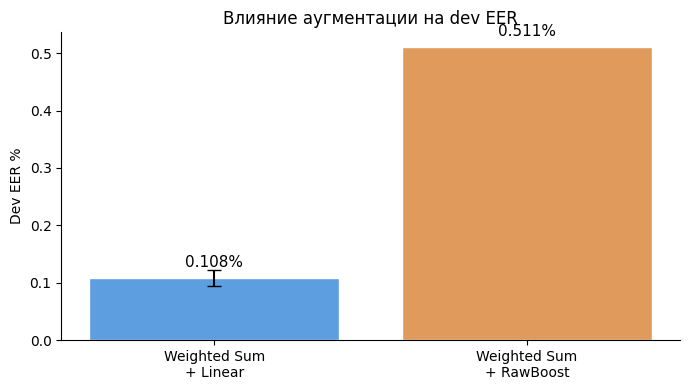

In [71]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Weighted Sum\n+ Linear", "Weighted Sum\n+ RawBoost"],
              [mean_, eer_with_rawboost],
              color=["#5c9ee0", "#e09b5c"], edgecolor="white")
ax.errorbar(0, mean_, yerr=std_, fmt="none", ecolor="black", capsize=5)
for bar, val in zip(bars, [mean_, eer_with_rawboost]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}%", ha="center", fontsize=11)
ax.set_ylabel("Dev EER %")
ax.set_title("Влияние аугментации на dev EER", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 8. t-SNE эмбеддингов (dev)

In [ ]:
probe.eval()
with torch.no_grad():
    w = torch.softmax(probe.layer_weights, dim=0).cpu().numpy()  # (25,)

agg_embeddings = (dev_feats * w[None, :, None]).sum(axis=1)  # (N, 1024)
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
embeddings_2d = tsne.fit_transform(agg_embeddings)

print("t-SNE завершён")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE завершён


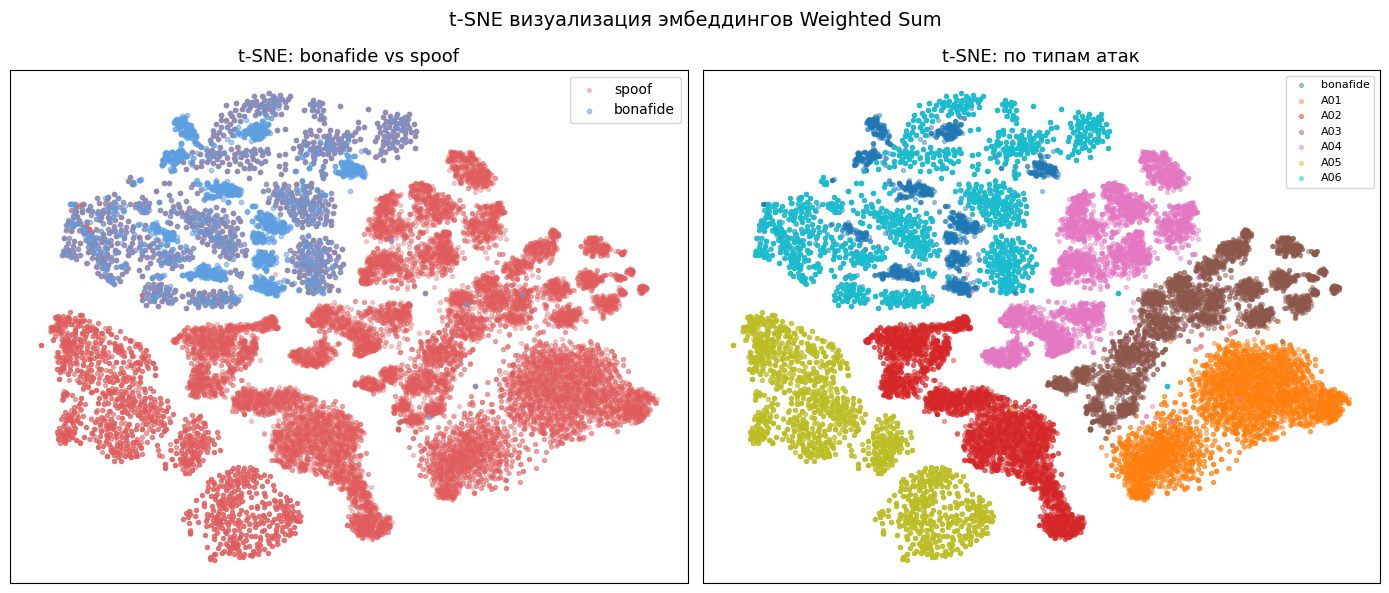

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# слева: bonafide vs spoof
ax = axes[0]
mask_bon = dev_labels == 1
mask_spo = dev_labels == 0
ax.scatter(embeddings_2d[mask_spo, 0], embeddings_2d[mask_spo, 1],
           c="#e05c5c", alpha=0.3, s=8, label="spoof")
ax.scatter(embeddings_2d[mask_bon, 0], embeddings_2d[mask_bon, 1],
           c="#5c9ee0", alpha=0.5, s=10, label="bonafide")
ax.set_title("t-SNE: bonafide vs spoof", fontsize=13)
ax.legend()
ax.set_xticks([]); ax.set_yticks([])

# справа: по типам атак
ax = axes[1]
dev_df_attacks = dev_df.reset_index(drop=True)
attack_colors = plt.cm.tab10(np.linspace(0, 1, 7))
attack_list = ["-"] + sorted(dev_df_attacks[dev_df_attacks.attack != "-"].attack.unique())

for i, atk in enumerate(attack_list):
    mask = (dev_df_attacks.attack == atk).values
    label = "bonafide" if atk == "-" else atk
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
               c=[attack_colors[i]], alpha=0.4, s=8, label=label)
ax.set_title("t-SNE: по типам атак", fontsize=13)
ax.legend(fontsize=8, loc="best")
ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("t-SNE визуализация эмбеддингов Weighted Sum", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Сводная таблица экспериментов (dev)

            Эксперимент     EER%        Примечание
     Weighted Sum + MLP 0.097367   ±0.018%, 3 сида
  Weighted Sum + Linear 0.108206   ±0.013%, 3 сида
     Fine-tuning T6-T12 0.235539 1 сид, 30% данных
Weighted Sum + RawBoost 0.510753    1 сид, 3 эпохи
               Baseline 1.829000   ±0.019%, 3 сида


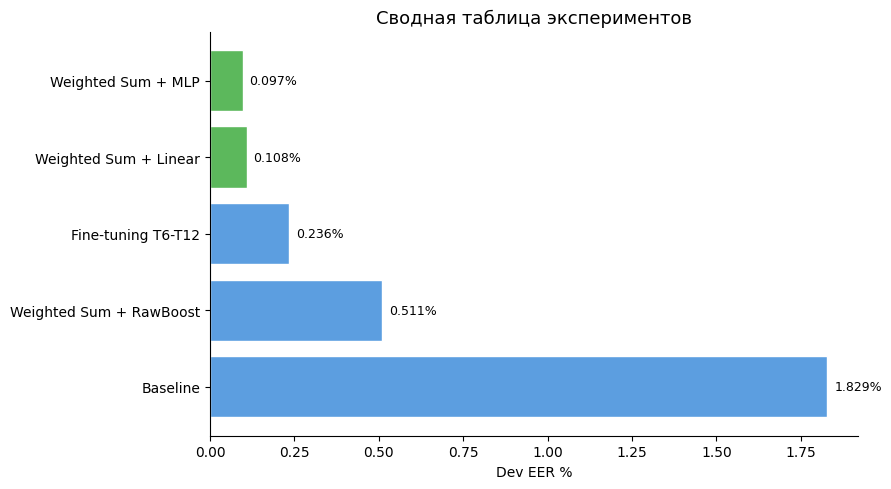

In [76]:
# из вывода 3 сидов baseline
baseline_mean = 1.829
baseline_std  = 0.019

summary_rows = [
    {"Эксперимент": "Baseline",   "EER%": baseline_mean, "Примечание": f"±{baseline_std:.3f}%, 3 сида"},
    {"Эксперимент": "Weighted Sum + Linear",         "EER%": mean_,         "Примечание": f"±{std_:.3f}%, 3 сида"},
    {"Эксперимент": "Weighted Sum + MLP",            "EER%": mlp_mean,      "Примечание": f"±{mlp_std:.3f}%, 3 сида"},
    {"Эксперимент": "Fine-tuning T6-T12",            "EER%": best_ft_eer,   "Примечание": "1 сид, 30% данных"},
    {"Эксперимент": "Weighted Sum + RawBoost",  "EER%": eer_with_rawboost, "Примечание": "1 сид, 3 эпохи"},
]

summary_df = pd.DataFrame(summary_rows).sort_values("EER%")
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#5cb85c" if e in ("Weighted Sum + Linear", "Weighted Sum + MLP") else "#5c9ee0"
          for e in summary_df["Эксперимент"]]
bars = ax.barh(summary_df["Эксперимент"], summary_df["EER%"], color=colors, edgecolor="white")
for bar, val in zip(bars, summary_df["EER%"]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f"{val:.3f}%",
            va="center", fontsize=9)
ax.set_xlabel("Dev EER %")
ax.set_title("Сводная таблица экспериментов", fontsize=13)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()